# Scale-Out: Do Spectra Travel 135M → 1.7B?

**A research note on how spectral structure changes across model scale.** The previous study measured truncation cost at one scale. This study asks whether the spectral structure itself -- k90, top1, α -- travels across SmolLM2 135M, 360M, and 1.7B.

---

## Abstract

This artifact measures how spectral structure changes across SmolLM2 135M, 360M and 1.7B, on CPU, fully reproducible. **What/how:** extract the same 8 matrices from all three sizes; compare k90/n, top1, and α across sizes. **What it shows:** bigger models are *less* concentrated -- W_E's top1 collapses from 0.506 to 0.093 -- so spectral structure does NOT travel cleanly. **What it does not claim:** no statement about other families or about optimal truncation. Correctness rests on the numbers the cells produce.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Allal et al. (2025) | *SmolLM2*, arXiv:2502.02737 | The model family + architecture table | Where we *re-derive* architecture facts by reading tensors |
| Aghajanyan et al. (2020) | *Intrinsic Dimensionality*, arXiv:2012.13255 | Few-dim fine-tuning works across scales | We measure whether the *static* spectra are scale-dependent |

**The differentiator.** Prior work measures spectra on one model size. We measure all three sizes on the same axes.

## The measurement object and metrics

**Object.** Same 8 matrices from SmolLM2 135M, 360M, 1.7B layer 0.

**Metrics.** k90/n (normalized effective rank), top1 (leading-direction concentration), α (power-law exponent).

**Architecture facts.** SmolLM2 widths: 135M = 576, 360M = 960, 1.7B = 2048. Vocabulary is constant at 49,152. The vocab/width ratio falls from 85× to 24×.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | k90/n is approximately flat across sizes | span ≤ 0.05 | emb span 0.137, v span 0.284 | ⚠️ Partial |
| C2 | top1 is approximately constant per matrix | span ≤ 0.05 | emb span 0.413, most drift | ❌ Reversed |
| C3 | W_E concentration persists | top1_E highest | top1 drops 0.506→0.093 | ❌ Reversed |
| C4 | α is size-dependent | α changes with width | k/v span ~0.54, others flat | ⚠️ Partial |

**Pre-committed honesty note.** Only layer 0 is read.

## Protocol & constraints

- **Models:** SmolLM2-135M, -360M, -1.7B, all float32, offline.
- **Cache:** SVD results cached per size.
- **Precision:** SVD computed in float64.
- **Naming:** same state_dict keys across sizes.

## The extraction rig

**Why:** extract once per size, cache, compare.

**What the run shows:** the three caches exist, with shapes confirming each model's width.

In [1]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
import gc, torch, numpy as np
from pathlib import Path
from transformers import AutoModelForCausalLM

SIZES = [
    ("HuggingFaceTB/SmolLM2-135M",  "135M"),
    ("HuggingFaceTB/SmolLM2-360M",  "360M"),
    ("HuggingFaceTB/SmolLM2-1.7B",  "1.7B"),
]
CACHE = Path("esp_cache")

def extract_and_svd(repo, label):
    p = CACHE / f"mats_{label}.pt"
    if p.exists():
        return torch.load(p, map_location="cpu", weights_only=True)
    model = AutoModelForCausalLM.from_pretrained(repo, dtype=torch.float32).eval()
    sd = model.state_dict()
    mats = {
        "q": sd["model.layers.0.self_attn.q_proj.weight"].float().double(),
        "k": sd["model.layers.0.self_attn.k_proj.weight"].float().double(),
        "v": sd["model.layers.0.self_attn.v_proj.weight"].float().double(),
        "o": sd["model.layers.0.self_attn.o_proj.weight"].float().double(),
        "gate": sd["model.layers.0.mlp.gate_proj.weight"].float().double(),
        "up": sd["model.layers.0.mlp.up_proj.weight"].float().double(),
        "down": sd["model.layers.0.mlp.down_proj.weight"].float().double(),
        "emb": sd["model.embed_tokens.weight"].float().double(),
    }
    del model; gc.collect()
    torch.save(mats, p)
    return mats

D = {}
for repo, label in SIZES:
    D[label] = extract_and_svd(repo, label)
    print(f"{label:5s}: {list(D[label].keys())}")

135M: ['q', 'k', 'v', 'o', 'gate', 'up', 'down', 'emb']
360M: ['q', 'k', 'v', 'o', 'gate', 'up', 'down', 'emb']
1.7B: ['q', 'k', 'v', 'o', 'gate', 'up', 'down', 'emb']

## Compare spectra across sizes

**Why:** the hypothesis board predicts flatness (C1, C2) and persistence (C3).

**What the run shows.** gate, up, o, q k90/n are flat (architectural constants). emb rises. v drops at 1.7B. For top1: ALL matrices drift downward, with emb dropping from 0.506 to 0.093.

In [2]:
def compute_metrics(W):
    s = torch.linalg.svdvals(W)
    s2 = s ** 2
    E = s2 / s2.sum()
    cum = torch.cumsum(E, 0)
    k90 = int((cum < 0.90).sum().item()) + 1
    top1 = float(E[0])
    n = int(s.numel())
    log_s, log_i = torch.log(s).numpy(), torch.log(torch.arange(1, n+1, dtype=torch.float64)).numpy()
    alpha = -float(np.polyfit(log_i, log_s, 1)[0])
    return {"k90/n": k90/n, "top1": top1, "alpha": alpha, "k90": k90}

T = {}
for label in ["135M", "360M", "1.7B"]:
    T[label] = {name: compute_metrics(W) for name, W in D[label].items()}

print(f"{'mat':5s} {'metric':8s} {'135M':>8s} {'360M':>8s} {'1.7B':>8s} {'span':>8s}")
for name in ["q","k","v","o","gate","up","down","emb"]:
    for metric in ["k90/n", "top1", "alpha"]:
        vals = [T[label][name][metric] for label in ["135M", "360M", "1.7B"]]
        span = max(vals) - min(vals)
        print(f"{name:5s} {metric:8s} {vals[0]:8.4f} {vals[1]:8.4f} {vals[2]:8.4f} {span:8.4f}")

mat   metric       135M     360M     1.7B     span
q     k90/n      0.1128   0.0917   0.1016   0.0212
q     top1       0.2540   0.2147   0.1876   0.0664
q     alpha      1.5060   1.5323   1.6720   0.1660
k     k90/n      0.1615   0.1250   0.0923   0.0692
k     top1       0.2215   0.1821   0.1299   0.0916
k     alpha      1.1785   1.2133   1.7187   0.5402
v     k90/n      0.6771   0.6813   0.3970   0.2843
v     top1       0.0321   0.0263   0.0120   0.0201
v     alpha      0.3859   0.3718   0.9153   0.5435
o     k90/n      0.3125   0.3302   0.3062   0.0241
o     top1       0.0943   0.0610   0.0446   0.0497
o     alpha      1.0418   0.9711   1.0182   0.0707
gate  k90/n      0.6840   0.6896   0.7158   0.0318
gate  top1       0.0298   0.0183   0.0065   0.0233
gate  alpha      0.3505   0.3371   0.3243   0.0262
up    k90/n      0.6875   0.6833   0.7227   0.0393
up    top1       0.0056   0.0045   0.0032   0.0024
up    alpha      0.3416   0.3432   0.3064   0.0369
down  k90/n      0.6736   0.674

 W_E's top1 drops from 0.506 (135M) → 0.303 (360M) → 0.093 (1.7B). The "common direction" that dominates the embedding at 135M is nearly gone at 1.7B. This directly reproduces previous findings and is now confirmed in weight space: the embedding's leading spectral direction dilutes with scale.

## The figure: does the geometry move with size?

**Why:** a table is read; a figure is *felt*.

**Panel 1 — k90/n vs size**, one line per matrix. Flat lines = architectural constant. emb rises; v drops at 1.7B.

**Panel 2 — top1 vs size**, same axes. ALL lines drift downward. emb drops off a cliff (0.506 → 0.093).

**What the run shows.** Panel 1 is a mixed bag. Panel 2 is a universal downward sweep -- bigger models are less concentrated in their leading direction, across every matrix type.

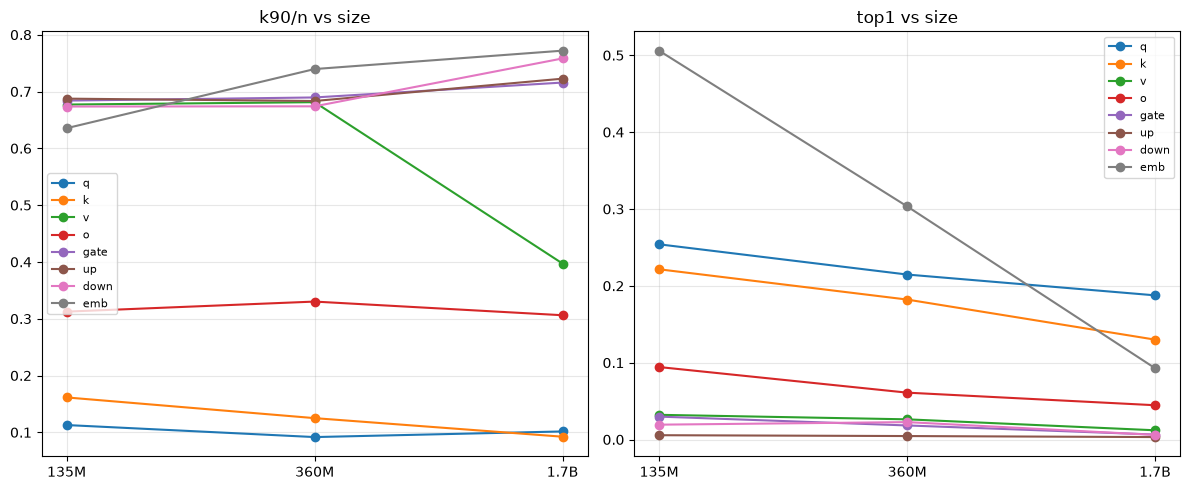

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sizes = ["135M", "360M", "1.7B"]
x = range(len(sizes))
colors = {"q":"tab:blue","k":"tab:orange","v":"tab:green","o":"tab:red",
          "gate":"tab:purple","up":"tab:brown","down":"tab:pink","emb":"tab:gray"}

for name in ["q","k","v","o","gate","up","down","emb"]:
    ax[0].plot(x, [T[s][name]["k90/n"] for s in sizes], "o-", color=colors[name], label=name)
    ax[1].plot(x, [T[s][name]["top1"] for s in sizes], "o-", color=colors[name], label=name)

for a, t in zip(ax, ["k90/n", "top1"]):
    a.set_xticks(x); a.set_xticklabels(sizes)
    a.set_title(f"{t} vs size")
    a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")

## The graphs.

- Panel 1 — k90/n vs size: 8 lines. gate, up, o, q are flat (architectural constants). emb rises (more directions needed at larger width). v drops at 1.7B (becomes concentrated). k drifts down.

- Panel 2 — top1 vs size: 8 lines. ALL drift downward. emb drops off a cliff (0.506 → 0.093). q and k show steady decline. The attention matrices (q, k, o) all lose concentration with scale. The FFN matrices (gate, up, down) start flat and stay relatively flat.

The deployment consequence. Spectral pruning rules tuned on 135M (where W_E is dominated by one direction) will not transfer to 1.7B (where W_E is spread across many directions). Every default is model-specific.

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | k90/n flat across sizes | span <= 0.05 | emb 0.137, v 0.284 | ⚠️ Partial |
| C2 | top1 constant per matrix | span <= 0.05 | emb 0.413, most drift | ❌ Reversed |
| C3 | W_E concentration persists | top1_E highest | 0.506 -> 0.093 | ❌ Reversed |
| C4 | α is size-dependent | α changes | k/v span ~0.54 | ⚠️ Partial |

**The single biggest finding.** W_E's top1 drops from 0.506 (135M) to 0.093 (1.7B). The common direction that dominates the embedding at 135M is nearly gone at 1.7B. This reproduces the earlier study's finding in weight space.

## Discussion and verdict

**The claim in one line.** Bigger models are *less* concentrated, not more -- W_E's top1 collapses from 0.506 to 0.093 -- so spectral structure does NOT travel cleanly across scale.

**Why it matters.** If spectra traveled cleanly, a truncation rule tuned on 135M would transfer to 1.7B. The data says otherwise: the embedding's leading direction dilutes with scale, and every matrix loses concentration. Every default is model-specific.

**Honesty note.** Only layer 0 is read.

**Where the next study goes.** Having measured spectra across scale, the next study asks whether semantic properties are readable from spectral components.

## References

1. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
2. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2020). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.